## Introduction

The objective of this analysis is to apply statistical concepts to the cleaned House Prices datasets. The analysis covers descriptive statistics, probability distributions, hypothesis testing, and correlation analysis to understand patterns within the datasets and support data-driven decision-making.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")

In [73]:
housing = pd.read_csv("Housing_Cleaned.csv")

In [74]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [75]:
housing.var(numeric_only=True)

price        3.498544e+12
area         4.709512e+06
bedrooms     5.447383e-01
bathrooms    2.524757e-01
stories      7.525432e-01
parking      7.423300e-01
dtype: float64

In [76]:
housing.std(numeric_only=True)

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64

In [77]:
housing.median(numeric_only=True)

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64

In [78]:
housing.mode().iloc[0]

price                      3500000
area                        6000.0
bedrooms                       3.0
bathrooms                      1.0
stories                        2.0
mainroad                       yes
guestroom                       no
basement                        no
hotwaterheating                 no
airconditioning                 no
parking                        0.0
prefarea                        no
furnishingstatus    semi-furnished
Name: 0, dtype: object

In [79]:
# Statistical Summary:
# House price and area show the greatest variability.
# The typical property has three bedrooms and one bathroom.

In [80]:
#Probability Distributions

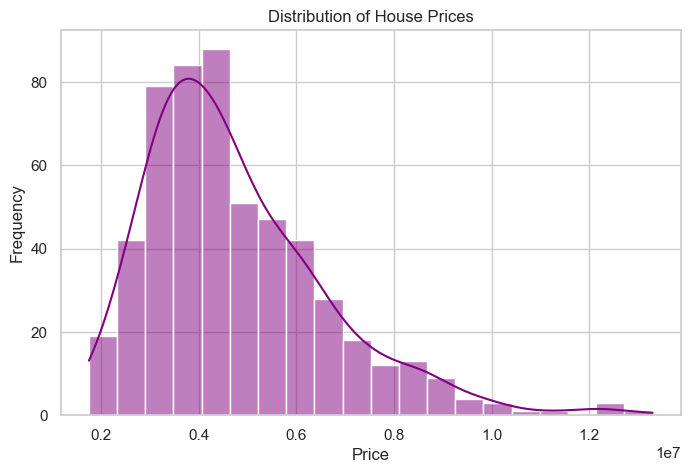

In [81]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=housing,
    x="price",
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("house_price_distribution.png", dpi=300)
plt.show()

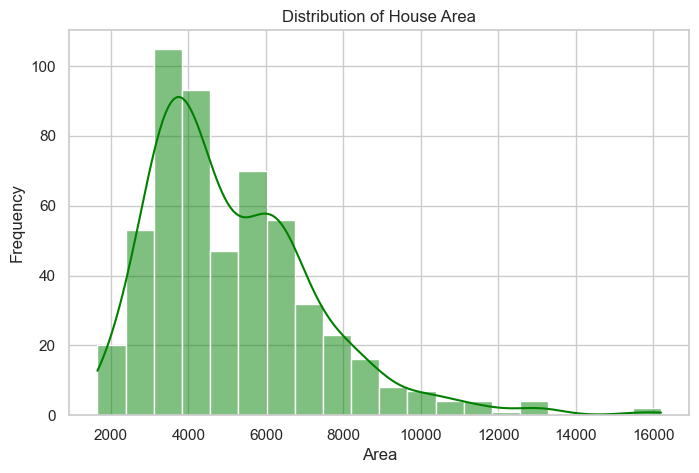

In [82]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=housing,
    x="area",
    bins=20,
    kde=True,
    color="green"
)

plt.title("Distribution of House Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

In [83]:
print("Price Skewness:", housing["price"].skew())
print("Area Skewness:", housing["area"].skew())

Price Skewness: 1.2122388370279802
Area Skewness: 1.321188343153483


In [84]:
# Probability Distribution Summary:
# - House Price is highly positively skewed (skewness = 1.212), indicating that most houses are moderately priced, while a few luxury properties have very high prices.
# - Area is also highly positively skewed (skewness = 1.321), showing that most houses have moderate sizes, with a small number of exceptionally large properties.
# - Both variables are not normally distributed due to the presence of high-value outliers.

In [85]:
##Hypothesis Test

In [86]:
#Research Question
#Is there a significant difference in the average price of houses with air conditioning and those without air conditioning?

In [87]:
# Hypothesis
# H0: There is no significant difference in the average price of houses with and without air conditioning.

# H1: There is a significant difference in the average price of houses with and without air conditioning.

In [88]:
# House prices with air conditioning
ac = housing[housing["airconditioning"] == "yes"]["price"]

# House prices without air conditioning
no_ac = housing[housing["airconditioning"] == "no"]["price"]

In [89]:
t_stat, p_value = ttest_ind(
    ac,
    no_ac,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 10.659244165528918
P-value: 2.803701257609203e-22


In [90]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in the average house prices.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average house prices.")

Reject the null hypothesis.
There is a statistically significant difference in the average house prices.


In [91]:
# Hypothesis Test Summary:
# The p-value is far below the significance level (0.05), so we reject the null hypothesis.
# This indicates a statistically significant difference in the average house prices
# of homes with and without air conditioning.

In [92]:
##Correlation Matrix

In [93]:
housing_corr = housing.corr(numeric_only=True)

print(housing_corr)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


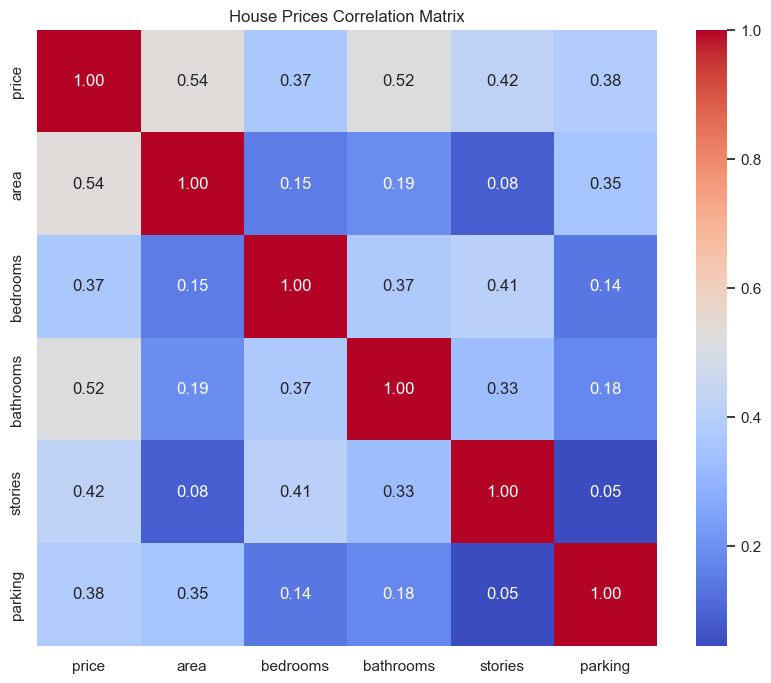

In [94]:
plt.figure(figsize=(10,8))

sns.heatmap(
    housing_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("House Prices Correlation Matrix")
plt.savefig("housing_cmp.png", dpi=300)
plt.show()

In [95]:
# Correlation Summary:
# Area has the strongest positive correlation with house price (r = 0.54).
# Bathrooms also have a strong positive relationship with price (r = 0.52).
# Stories, Parking, and Bedrooms show moderate positive correlations with house prices.

In [96]:
# Correlation vs Causation:
# Correlation measures the strength and direction of a relationship between variables, while causation means that one variable directly causes changes in another.
# Although Area and Price are positively correlated, this does not prove that increasing the area alone causes higher prices, since other factors such as
# location, amenities, and property condition may also influence price.

In [97]:
# Feature Importance:
# Area, Bathrooms, and Stories are the strongest predictors of price.
# No pair of predictor variables shows a very high correlation (|r| > 0.8), suggesting that there are no strongly redundant features in either dataset.